<a href="https://colab.research.google.com/github/saradindu-chaudhuri/Longitudinal_Trajectory_Cognitive_Risk/blob/main/Cohort_Generation_%26_Baseline_Cox_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install statsmodels pandas numpy matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Simulate 4-Wave Longitudinal Cohort (0, 2, 4, 6 Years)
np.random.seed(42)
n_subjects = 200
time_points = [0, 2, 4, 6]

records = []
for sub_id in range(1, n_subjects + 1):
    # Baseline Subject Characteristics
    age_base = np.random.normal(75, 5)
    apoe4 = np.random.choice([0, 1], p=[0.7, 0.3]) # 30% carrier prevalence
    hippocampal_vol = np.random.normal(3200, 300) - (apoe4 * 150) # mm3

    # Random Intercept (individual starting cognitive level) & Random Slope (rate of decline)
    rand_intercept = np.random.normal(0, 1.5)
    rand_slope = np.random.normal(0, 0.3)

    for t in time_points:
        # Cognitive Score (ACE-III scale: 0-100)
        # Main Effects: Time, APOE4, Baseline Hippocampal Volume
        # Interaction: APOE4 x Time (APOE4 accelerates decline)
        mmse_base = 88.0
        time_effect = -0.8 * t
        apoe_effect = -1.2 * apoe4
        hippo_effect = 0.004 * (hippocampal_vol - 3200)
        interaction_effect = -0.6 * (apoe4 * t)

        noise = np.random.normal(0, 1.2)

        score = mmse_base + time_effect + apoe_effect + hippo_effect + interaction_effect + rand_intercept + (rand_slope * t) + noise
        score_clipped = np.clip(score, 0, 100)

        records.append({
            'Subject_ID': sub_id,
            'Years': t,
            'Age_Baseline': age_base,
            'APOE4_Carrier': apoe4,
            'Hippocampal_Vol_mm3': hippocampal_vol,
            'Cognitive_Score': score_clipped
        })

df_cheba = pd.DataFrame(records)
print("--- LONGITUDINAL COHORT PREVIEW (First 10 Rows) ---")
print(df_cheba.head(10))

# 2. Fit Linear Mixed-Effects Model (LME)
# Fixed Effects: Years, APOE4_Carrier, Hippocampal_Vol_mm3, Years:APOE4_Carrier
# Random Effects: Random Intercept per Subject (1 | Subject_ID)
lme_model = smf.mixedlm(
    "Cognitive_Score ~ Years * APOE4_Carrier + Hippocampal_Vol_mm3 + Age_Baseline",
    data=df_cheba,
    groups=df_cheba["Subject_ID"]
)
lme_result = lme_model.fit()

print("\n--- CHeBA LONGITUDINAL MIXED-EFFECTS MODEL SUMMARY ---")
print(lme_result.summary())

--- LONGITUDINAL COHORT PREVIEW (First 10 Rows) ---
   Subject_ID  Years  Age_Baseline  APOE4_Carrier  Hippocampal_Vol_mm3  \
0           1      0     77.483571              1          3008.520710   
1           1      2     77.483571              1          3008.520710   
2           1      4     77.483571              1          3008.520710   
3           1      6     77.483571              1          3008.520710   
4           2      0     72.143099              0          2922.775149   
5           2      2     72.143099              0          2922.775149   
6           2      4     72.143099              0          2922.775149   
7           2      6     72.143099              0          2922.775149   
8           3      0     82.328244              0          3132.267110   
9           3      2     82.328244              0          3132.267110   

   Cognitive_Score  
0        84.701112  
1        82.970222  
2        78.451892  
3        75.910083  
4        83.088327  
5      

/tmp/ipykernel_878/3044897746.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(


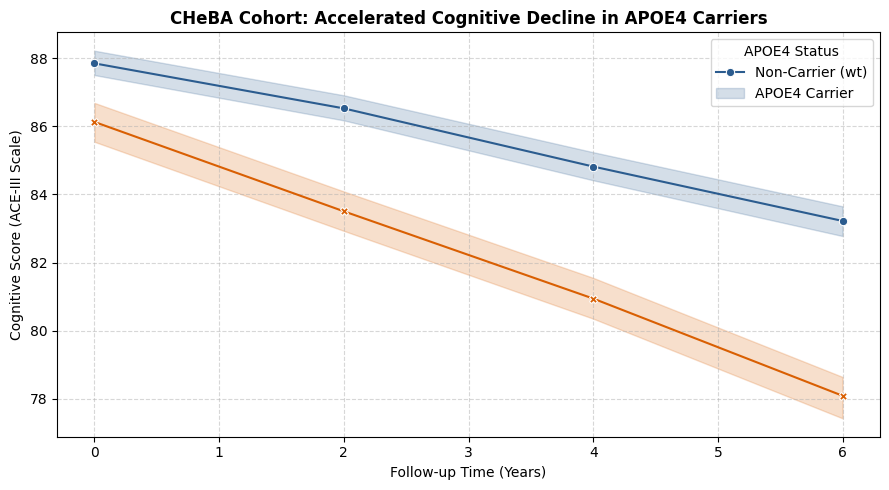

In [3]:
# Plot Cognitive Decline Trajectories by APOE4 Status
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=df_cheba,
    x="Years",
    y="Cognitive_Score",
    hue="APOE4_Carrier",
    style="APOE4_Carrier",
    markers=True,
    dashes=False,
    palette={0: "#2b5c8f", 1: "#d95f02"},
    err_style="band",
    ci=95
)

plt.title("CHeBA Cohort: Accelerated Cognitive Decline in APOE4 Carriers", fontsize=12, fontweight='bold')
plt.xlabel("Follow-up Time (Years)", fontsize=10)
plt.ylabel("Cognitive Score (ACE-III Scale)", fontsize=10)
plt.legend(title="APOE4 Status", labels=["Non-Carrier (wt)", "APOE4 Carrier"], frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Simulate Longitudinal Cohort with Structural MRI & Vascular Biomarkers
np.random.seed(101)
n_subjects = 250
time_points = [0, 2, 4, 6]

records_mri = []
for sub_id in range(1, n_subjects + 1):
    age_base = np.random.normal(74, 4.5)
    apoe4 = np.random.choice([0, 1], p=[0.72, 0.28])

    # Baseline Biomarkers
    base_hippo = np.random.normal(3300, 280) - (apoe4 * 120)  # mm3
    wmh_volume = np.random.lognormal(mean=1.5, sigma=0.6)     # cm3 (vascular lesion burden)

    # Atrophy Rate (mm3/year loss) - accelerated by APOE4 and WMH
    annual_atrophy = np.random.normal(35, 10) + (apoe4 * 18) + (wmh_volume * 2.5)

    rand_intercept = np.random.normal(0, 1.2)
    rand_slope = np.random.normal(0, 0.25)

    for t in time_points:
        # Time-varying Hippocampal Volume
        current_hippo = base_hippo - (annual_atrophy * t)

        # Cognitive Score Mechanics
        mmse_base = 90.0
        time_effect = -0.5 * t
        apoe_effect = -1.0 * apoe4
        hippo_effect = 0.005 * (current_hippo - 3300)
        wmh_effect = -0.45 * wmh_volume

        # Interaction: Atrophy Rate x WMH Burden (Vascular + Neurodegenerative Synergy)
        synergy_effect = -0.12 * (wmh_volume * t)

        noise = np.random.normal(0, 1.1)

        score = (mmse_base + time_effect + apoe_effect + hippo_effect
                 + wmh_effect + synergy_effect + rand_intercept + (rand_slope * t) + noise)

        records_mri.append({
            'Subject_ID': sub_id,
            'Years': t,
            'Age_Baseline': age_base,
            'APOE4_Carrier': apoe4,
            'Hippocampal_Vol_mm3': current_hippo,
            'WMH_Volume_cm3': wmh_volume,
            'Cognitive_Score': np.clip(score, 0, 100)
        })

df_mri = pd.DataFrame(records_mri)
print("--- DUAL-PATHOLOGY COHORT LOADED (First 5 Rows) ---")
print(df_mri[['Subject_ID', 'Years', 'APOE4_Carrier', 'Hippocampal_Vol_mm3', 'WMH_Volume_cm3', 'Cognitive_Score']].head())

# 2. Fit Multi-Modal Linear Mixed-Effects Model
lme_mri = smf.mixedlm(
    "Cognitive_Score ~ Years * WMH_Volume_cm3 + Hippocampal_Vol_mm3 + APOE4_Carrier + Age_Baseline",
    data=df_mri,
    groups=df_mri["Subject_ID"]
)
lme_mri_result = lme_mri.fit()

print("\n--- MULTI-MODAL CHeBA MIXED-EFFECTS MODEL SUMMARY ---")
print(lme_mri_result.summary())

--- DUAL-PATHOLOGY COHORT LOADED (First 5 Rows) ---
   Subject_ID  Years  APOE4_Carrier  Hippocampal_Vol_mm3  WMH_Volume_cm3  \
0           1      0              0          3475.877158        6.129301   
1           1      2              0          3393.732724        6.129301   
2           1      4              0          3311.588290        6.129301   
3           1      6              0          3229.443855        6.129301   
4           2      0              1          3039.473443        5.018932   

   Cognitive_Score  
0        87.853195  
1        85.679734  
2        82.885699  
3        78.712984  
4        84.528837  

--- MULTI-MODAL CHeBA MIXED-EFFECTS MODEL SUMMARY ---
             Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  Cognitive_Score
No. Observations:  1000     Method:              REML           
No. Groups:        250      Scale:               1.7440         
Min. group size:   4        Log-Likelihood:      -1923.4127     

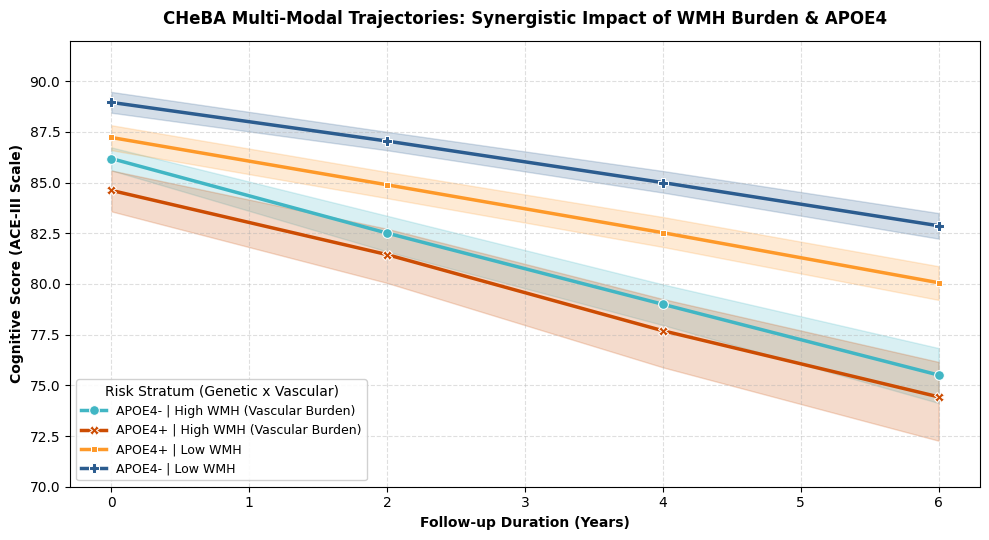

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Stratify WMH Burden via Median Split
wmh_median = df_mri['WMH_Volume_cm3'].median()
df_mri['WMH_Group'] = np.where(df_mri['WMH_Volume_cm3'] >= wmh_median, 'High WMH (Vascular Burden)', 'Low WMH')

# Create a Combined Stratification Variable
df_mri['Stratum'] = df_mri.apply(
    lambda row: f"{'APOE4+' if row['APOE4_Carrier'] == 1 else 'APOE4-'} | {row['WMH_Group']}",
    axis=1
)

# 2. Define Custom Color Palette for the 4 Strata
palette = {
    'APOE4- | Low WMH': '#2b5c8f',                   # Baseline (Low Risk) - Dark Blue
    'APOE4- | High WMH (Vascular Burden)': '#41b6c4', # Vascular Risk Only - Light Blue/Teal
    'APOE4+ | Low WMH': '#fe9929',                   # Genetic Risk Only - Orange
    'APOE4+ | High WMH (Vascular Burden)': '#cc4c02' # Dual Pathology (Highest Risk) - Dark Red
}

# 3. Plot Longitudinal Cognitive Decay Trajectories
plt.figure(figsize=(10, 5.5))
ax = sns.lineplot(
    data=df_mri,
    x="Years",
    y="Cognitive_Score",
    hue="Stratum",
    style="Stratum",
    markers=True,
    dashes=False,
    palette=palette,
    linewidth=2.5,
    markersize=7,
    err_style="band",
    errorbar=("ci", 95)
)

plt.title("CHeBA Multi-Modal Trajectories: Synergistic Impact of WMH Burden & APOE4", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Follow-up Duration (Years)", fontsize=10, fontweight='bold')
plt.ylabel("Cognitive Score (ACE-III Scale)", fontsize=10, fontweight='bold')
plt.ylim(70, 92)
plt.grid(True, linestyle="--", alpha=0.4)

# Format Legend
plt.legend(
    title="Risk Stratum (Genetic x Vascular)",
    title_fontsize='10',
    fontsize='9',
    loc='lower left',
    frameon=True,
    facecolor='white',
    framealpha=0.9
)

plt.tight_layout()
plt.show()